# Feature Extraction & Modeling
**Thesis:** Structured Subsystem-Aware Feature Representations for Predictive Maintenance in Metro Systems  
**Author:** Emirhan Kurtulus

**Goal:** Compare three feature set modes on the same RF pipeline to isolate the effect of subsystem-aware grouping:
1. **Flat** — per-sensor features only (Stefan's baseline)
2. **Engineering** — per-sensor + domain-knowledge group features
3. **Data-driven** — per-sensor (excl. noise) + NB02 cluster-based group features

**Setup:** Same RF hyperparameters and window config as Stefan Helm's thesis (controlled comparison).

**Metrics:** F1, precision, recall, false-alarm rate

## 0. Imports & Setup

In [1]:
import sys, os, gc
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
from src.config import (
    TRAIN_GLOB_PORTABLE as TRAIN_PATH,
    TEST_GLOB_PORTABLE as TEST_PATH,
    SUBSYSTEMS,
)
from src.features import (
    extract_window_features,
    ALL_SENSOR_COLS, ANALOG_COLS, BINARY_COLS,
    ENGINEERING_GROUPS, DATA_DRIVEN_GROUPS, C1_NOISE_SENSORS,
)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 11

META_COLS = ['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE',
             'TRAIN_IS_IN_MAINTENANCE', 'TRAIN_MAINTENANCE_TYPE',
             'year', 'month', 'day']

# Window & label config (Stefan's best: 350s window, 6.2h horizon)
WINDOW_S = 350
HORIZON_H = 6.2
MIN_ROWS = int(WINDOW_S * 0.8)

# Asset data paths
ASSET_DIR = os.path.join('..', 'data', 'asset_data')
FAILURE_CSV = os.path.join(ASSET_DIR, 'failure.csv')
REVISION_CSV = os.path.join(ASSET_DIR, 'revision.csv')

print(f'Window: {WINDOW_S}s ({WINDOW_S/60:.1f} min) | Horizon: {HORIZON_H}h')
print(f'Feature modes: flat, engineering ({len(ENGINEERING_GROUPS)} groups), data_driven ({len(DATA_DRIVEN_GROUPS)} groups)')
print(f'Noise sensors excluded in data_driven mode: {len(C1_NOISE_SENSORS)}')
print('Setup done.')

Window: 350s (5.8 min) | Horizon: 6.2h
Feature modes: flat, engineering (8 groups), data_driven (4 groups)
Noise sensors excluded in data_driven mode: 67
Setup done.


## 1. Load Asset Data & Define Failure Events

Parse failure.csv and revision.csv for `days_since_last_failure` and `days_since_last_revision` features.  
Define failure events from the sensor data for labeling.

In [2]:
# Parse asset failure dates
fail_asset = pd.read_csv(FAILURE_CSV, sep=';', encoding='utf-8-sig')
fail_dates = pd.to_datetime(
    fail_asset.iloc[:, 0].astype(str) + ' ' + fail_asset.iloc[:, 1].astype(str),
    dayfirst=True, errors='coerce'
).dropna().sort_values().tolist()
print(f'Asset failure records: {len(fail_dates)}')

# Parse revision dates
rev_asset = pd.read_csv(REVISION_CSV, sep=';', encoding='utf-8-sig')
rev_dates = pd.to_datetime(rev_asset['start'], dayfirst=True, errors='coerce').dropna().sort_values().tolist()
print(f'Asset revision records: {len(rev_dates)}')

def get_asset_features(window_end):
    """Days since last failure/revision before window_end."""
    past_f = [t for t in fail_dates if t < window_end]
    past_r = [t for t in rev_dates if t < window_end]
    return {
        'days_since_last_failure': (window_end - past_f[-1]).days if past_f else 999,
        'days_since_last_revision': (window_end - past_r[-1]).days if past_r else 999,
    }

Asset failure records: 40
Asset revision records: 21


In [3]:
# Extract failure events from sensor data (streaming)
def get_failure_events(path_pattern):
    files = sorted(glob.glob(path_pattern, recursive=True))
    rows = []
    for f in files:
        df = pd.read_parquet(f, columns=['TIMESTAMP', 'TRAIN_IS_IN_FAILURE', 'TRAIN_FAILURE_TYPE'])
        df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
        rows.append(df[df['TRAIN_IS_IN_FAILURE']])
        del df
    fail = pd.concat(rows, ignore_index=True).sort_values('TIMESTAMP').reset_index(drop=True)
    del rows
    fail['_grp'] = (fail['TIMESTAMP'].diff() > pd.Timedelta(hours=1)).cumsum()
    events = (
        fail.groupby('_grp')
        .agg(onset=('TIMESTAMP', 'min'), end=('TIMESTAMP', 'max'),
             failure_type=('TRAIN_FAILURE_TYPE', 'first'))
        .reset_index(drop=True)
    )
    # Map failure types to short labels
    type_map = {'Brake System Failure': 'Brake', 'Compressor Module Failure': 'Compressor',
                'Leveling System Failure': 'Leveling'}
    events['type'] = events['failure_type'].map(type_map).fillna('Other')
    return events

train_events = get_failure_events(TRAIN_PATH)
test_events = get_failure_events(TEST_PATH)
print(f'Train failure events: {len(train_events)}')
print(f'Test failure events: {len(test_events)}')
gc.collect()

Train failure events: 16
Test failure events: 29


0

## 2. Feature Extraction (streaming)

Stream through parquet files day by day. For each 350s non-overlapping window:
1. Skip if < 280 rows (sparse data)
2. Skip if overlaps with maintenance
3. Compute per-sensor features (mean/std/min/max for analog, active_s/flips for binary)
4. Compute group-level features for each mode
5. Label: 1 if any failure onset is within `HORIZON_H` hours after window end, or if failure is active in window

We extract features in all 3 modes simultaneously to ensure identical windows.

In [4]:
def label_window(win_start, win_end, events, horizon_h):
    """Label a window: 1 if failure active or approaching within horizon."""
    H = pd.Timedelta(hours=horizon_h)
    for _, ev in events.iterrows():
        # Failure active during window
        if ev['onset'] <= win_end and ev['end'] >= win_start:
            return 1, ev['type']
        # Failure approaching (onset within horizon after window end)
        if win_end < ev['onset'] <= win_end + H:
            return 1, ev['type']
    return 0, 'normal'

In [5]:
def extract_all_windows(path_pattern, events, label):
    """Stream through parquet files and extract features in all 3 modes."""
    files = sorted(glob.glob(path_pattern, recursive=True))
    print(f'[{label}] Processing {len(files)} files...')
    
    rows_flat = []
    rows_eng = []
    rows_dd = []
    meta_rows = []
    
    for fi, fpath in enumerate(files):
        df = pd.read_parquet(fpath)
        df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])
        df.sort_values('TIMESTAMP', inplace=True, ignore_index=True)
        
        if len(df) < MIN_ROWS:
            del df; continue
        
        # Assign windows
        epoch = df['TIMESTAMP'].iloc[0]
        secs = (df['TIMESTAMP'] - epoch).dt.total_seconds().astype(np.int64)
        df['_win'] = secs // WINDOW_S
        
        sensor_cols = [c for c in df.columns if c not in META_COLS and c != '_win']
        
        for wid, wdf in df.groupby('_win'):
            if len(wdf) < MIN_ROWS:
                continue
            # Skip maintenance windows
            if wdf['TRAIN_IS_IN_MAINTENANCE'].any():
                continue
            
            win_start = wdf['TIMESTAMP'].iloc[0]
            win_end = wdf['TIMESTAMP'].iloc[-1]
            
            # Label
            lbl, ftype = label_window(win_start, win_end, events, HORIZON_H)
            
            # Asset features
            asset = get_asset_features(win_end)
            
            # Sensor data (no meta columns)
            w_sensors = wdf[[c for c in ALL_SENSOR_COLS if c in wdf.columns]]
            
            # Extract features in all 3 modes
            f_flat = extract_window_features(w_sensors, asset, mode='flat')
            f_eng = extract_window_features(w_sensors, asset, mode='engineering')
            f_dd = extract_window_features(w_sensors, asset, mode='data_driven')
            
            rows_flat.append(f_flat)
            rows_eng.append(f_eng)
            rows_dd.append(f_dd)
            meta_rows.append({
                'win_start': win_start, 'win_end': win_end,
                'label': lbl, 'failure_type': ftype,
            })
        
        del df; gc.collect()
        if (fi + 1) % 50 == 0:
            print(f'  [{fi+1}/{len(files)}] windows: {len(meta_rows):,}')
    
    meta = pd.DataFrame(meta_rows)
    df_flat = pd.DataFrame(rows_flat)
    df_eng = pd.DataFrame(rows_eng)
    df_dd = pd.DataFrame(rows_dd)
    
    del rows_flat, rows_eng, rows_dd, meta_rows; gc.collect()
    
    n_pos = meta['label'].sum()
    print(f'[{label}] {len(meta):,} windows | pos={n_pos:,} ({100*n_pos/len(meta):.1f}%)')
    print(f'  flat: {df_flat.shape[1]} feats | eng: {df_eng.shape[1]} feats | dd: {df_dd.shape[1]} feats')
    
    return meta, df_flat, df_eng, df_dd

In [6]:
train_meta, train_flat, train_eng, train_dd = extract_all_windows(TRAIN_PATH, train_events, 'TRAIN')
gc.collect()
test_meta, test_flat, test_eng, test_dd = extract_all_windows(TEST_PATH, test_events, 'TEST')
gc.collect()

print(f'\nTrain: {len(train_meta):,} windows')
print(f'Test:  {len(test_meta):,} windows')

[TRAIN] Processing 246 files...


  [50/246] windows: 8,483


  [100/246] windows: 16,491


  [150/246] windows: 23,726


  [200/246] windows: 32,643


[TRAIN] 40,517 windows | pos=489 (1.2%)
  flat: 358 feats | eng: 398 feats | dd: 158 feats
[TEST] Processing 136 files...


  [50/136] windows: 8,199


  [100/136] windows: 16,034


[TEST] 21,554 windows | pos=583 (2.7%)
  flat: 358 feats | eng: 398 feats | dd: 158 feats

Train: 40,517 windows
Test:  21,554 windows


## 3. Train Random Forest (3 modes)

Same RF hyperparameters as Stefan Helm's best config:
- n_estimators=300, max_depth=4, min_samples_split=10, min_samples_leaf=4
- max_features='sqrt'

No undersampling or resampling — we compare modes on the same imbalanced data.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix

RF_PARAMS = dict(
    n_estimators=300,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
)

y_train = train_meta['label'].values
y_test = test_meta['label'].values

results = {}

for mode_name, X_tr, X_te in [
    ('flat', train_flat, test_flat),
    ('engineering', train_eng, test_eng),
    ('data_driven', train_dd, test_dd),
]:
    print(f'\n{"="*60}')
    print(f'Training RF — mode: {mode_name} ({X_tr.shape[1]} features)')
    print(f'{"="*60}')
    
    # Handle NaN (fill with 0 for missing sensors)
    X_tr_clean = X_tr.fillna(0).values
    X_te_clean = X_te.fillna(0).values
    
    rf = RandomForestClassifier(**RF_PARAMS)
    rf.fit(X_tr_clean, y_train)
    
    y_pred_train = rf.predict(X_tr_clean)
    y_pred_test = rf.predict(X_te_clean)
    
    # Metrics
    f1_tr = f1_score(y_train, y_pred_train)
    f1_te = f1_score(y_test, y_pred_test)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec = recall_score(y_test, y_pred_test, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0  # false alarm rate
    
    results[mode_name] = {
        'n_features': X_tr.shape[1],
        'f1_train': f1_tr, 'f1_test': f1_te,
        'precision': prec, 'recall': rec, 'far': far,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'model': rf,
    }
    
    print(f'  Train F1: {f1_tr:.3f}')
    print(f'  Test  F1: {f1_te:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f} | FAR: {far:.4f}')
    print(f'  Confusion: TP={tp} FP={fp} FN={fn} TN={tn}')
    print()
    print(classification_report(y_test, y_pred_test, target_names=['Normal', 'Failure']))


Training RF — mode: flat (358 features)


  Train F1: 0.131
  Test  F1: 0.000 | Prec: 0.000 | Rec: 0.000 | FAR: 0.0000
  Confusion: TP=0 FP=0 FN=583 TN=20971

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99     20971
     Failure       0.00      0.00      0.00       583

    accuracy                           0.97     21554
   macro avg       0.49      0.50      0.49     21554
weighted avg       0.95      0.97      0.96     21554


Training RF — mode: engineering (398 features)


  Train F1: 0.207
  Test  F1: 0.078 | Prec: 0.243 | Rec: 0.046 | FAR: 0.0040
  Confusion: TP=27 FP=84 FN=556 TN=20887

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.98     20971
     Failure       0.24      0.05      0.08       583

    accuracy                           0.97     21554
   macro avg       0.61      0.52      0.53     21554
weighted avg       0.95      0.97      0.96     21554


Training RF — mode: data_driven (158 features)


  Train F1: 0.217
  Test  F1: 0.000 | Prec: 0.000 | Rec: 0.000 | FAR: 0.0001
  Confusion: TP=0 FP=2 FN=583 TN=20969

              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99     20971
     Failure       0.00      0.00      0.00       583

    accuracy                           0.97     21554
   macro avg       0.49      0.50      0.49     21554
weighted avg       0.95      0.97      0.96     21554



## 4. Results Comparison

## 3b. Improved Models — Deeper RF + Gradient Boosting + Threshold Tuning

Section 3 used Stefan's exact hyperparameters (max_depth=4) as a controlled replication.
Now we lift the depth constraint and try gradient boosting to see if the feature representations
can actually separate failures when the model has enough capacity.

**Models:**
1. **RF-Deep** — RF with max_depth=None (full depth), more trees
2. **GradientBoosting** — sequential boosting, better at rare-class learning
3. **Threshold-tuned** — optimize decision threshold on train set to maximize F1

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold

def find_best_threshold(model, X, y):
    """Find the probability threshold that maximizes F1 on the given data."""
    proba = model.predict_proba(X)[:, 1]
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (proba >= t).astype(int)
        f1 = f1_score(y, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5):
    """Evaluate a model at a given threshold."""
    proba_tr = model.predict_proba(X_train)[:, 1]
    proba_te = model.predict_proba(X_test)[:, 1]
    
    pred_tr = (proba_tr >= threshold).astype(int)
    pred_te = (proba_te >= threshold).astype(int)
    
    f1_tr = f1_score(y_train, pred_tr, zero_division=0)
    f1_te = f1_score(y_test, pred_te, zero_division=0)
    prec = precision_score(y_test, pred_te, zero_division=0)
    rec = recall_score(y_test, pred_te, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, pred_te).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    return {
        'f1_train': f1_tr, 'f1_test': f1_te,
        'precision': prec, 'recall': rec, 'far': far,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        'threshold': threshold,
    }

# Imbalance ratio for sample_weight in GBM
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_ratio = neg_count / pos_count
print(f'Class imbalance: {neg_count:,} neg / {pos_count:,} pos = {scale_ratio:.1f}:1')

# Model configs to try
model_configs = {
    'RF-Deep': RandomForestClassifier(
        n_estimators=500, max_depth=None,
        min_samples_split=5, min_samples_leaf=2,
        max_features='sqrt', random_state=42,
        n_jobs=-1, class_weight='balanced',
    ),
    'GBM': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, min_samples_split=10, min_samples_leaf=5,
        random_state=42,
    ),
}

results_v2 = {}
datasets = {
    'flat': (train_flat, test_flat),
    'engineering': (train_eng, test_eng),
    'data_driven': (train_dd, test_dd),
}

for model_name, model_template in model_configs.items():
    for mode_name, (X_tr, X_te) in datasets.items():
        key = f'{model_name}__{mode_name}'
        print(f'\n{"="*60}')
        print(f'{key} ({X_tr.shape[1]} features)')
        print(f'{"="*60}')
        
        X_tr_c = X_tr.fillna(0).values
        X_te_c = X_te.fillna(0).values
        
        # For GBM, use sample_weight to handle imbalance
        from sklearn.base import clone
        model = clone(model_template)
        
        if 'GBM' in model_name:
            sw = np.where(y_train == 1, scale_ratio, 1.0)
            model.fit(X_tr_c, y_train, sample_weight=sw)
        else:
            model.fit(X_tr_c, y_train)
        
        # Default threshold (0.5)
        res_default = evaluate_model(model, X_tr_c, y_train, X_te_c, y_test, threshold=0.5)
        print(f'  [t=0.50] Train F1: {res_default["f1_train"]:.3f} | Test F1: {res_default["f1_test"]:.3f} | '
              f'Prec: {res_default["precision"]:.3f} | Rec: {res_default["recall"]:.3f} | FAR: {res_default["far"]:.4f}')
        print(f'           TP={res_default["tp"]} FP={res_default["fp"]} FN={res_default["fn"]} TN={res_default["tn"]}')
        
        # Optimized threshold (on train set)
        best_t, best_f1_tr = find_best_threshold(model, X_tr_c, y_train)
        res_tuned = evaluate_model(model, X_tr_c, y_train, X_te_c, y_test, threshold=best_t)
        print(f'  [t={best_t:.2f}] Train F1: {res_tuned["f1_train"]:.3f} | Test F1: {res_tuned["f1_test"]:.3f} | '
              f'Prec: {res_tuned["precision"]:.3f} | Rec: {res_tuned["recall"]:.3f} | FAR: {res_tuned["far"]:.4f}')
        print(f'           TP={res_tuned["tp"]} FP={res_tuned["fp"]} FN={res_tuned["fn"]} TN={res_tuned["tn"]}')
        
        results_v2[key] = {
            'model_name': model_name, 'mode': mode_name,
            'n_features': X_tr.shape[1],
            'default': res_default, 'tuned': res_tuned,
            'best_threshold': best_t, 'model': model,
        }

print('\nDone — all models trained.')

In [ ]:
# Comprehensive comparison table — all models, both thresholds
rows = []
for key, info in results_v2.items():
    for variant, res in [('default', info['default']), ('tuned', info['tuned'])]:
        rows.append({
            'model': info['model_name'],
            'features': info['mode'],
            'threshold': variant,
            'n_feat': info['n_features'],
            't_value': res['threshold'],
            'f1_train': res['f1_train'],
            'f1_test': res['f1_test'],
            'precision': res['precision'],
            'recall': res['recall'],
            'far': res['far'],
            'tp': res['tp'], 'fp': res['fp'],
            'fn': res['fn'], 'tn': res['tn'],
        })

# Add Section 3 results (Stefan's RF) for comparison
for mode_name, vals in results.items():
    rows.append({
        'model': 'RF-Shallow', 'features': mode_name,
        'threshold': 'default', 'n_feat': vals['n_features'],
        't_value': 0.5,
        'f1_train': vals['f1_train'], 'f1_test': vals['f1_test'],
        'precision': vals['precision'], 'recall': vals['recall'],
        'far': vals['far'],
        'tp': vals['tp'], 'fp': vals['fp'],
        'fn': vals['fn'], 'tn': vals['tn'],
    })

comp_df = pd.DataFrame(rows)
print('='*80)
print('FULL MODEL COMPARISON (sorted by Test F1)')
print('='*80)
print(comp_df.sort_values('f1_test', ascending=False)[
    ['model', 'features', 'threshold', 'n_feat', 't_value',
     'f1_train', 'f1_test', 'precision', 'recall', 'far', 'tp', 'fp']
].to_string(index=False))

# Best result
best = comp_df.loc[comp_df['f1_test'].idxmax()]
print(f'\n*** Best: {best["model"]} + {best["features"]} (t={best["t_value"]:.2f}) → Test F1={best["f1_test"]:.3f} ***')
print(f'    Stefan reference: Test F1=0.21')

In [ ]:
# Bar chart: Test F1 for tuned-threshold models only
tuned = comp_df[comp_df['threshold'] == 'tuned'].copy()
# Also add RF-Shallow default for reference
shallow = comp_df[comp_df['model'] == 'RF-Shallow'].copy()
plot_df = pd.concat([tuned, shallow], ignore_index=True)
plot_df['label'] = plot_df['model'] + '\n' + plot_df['features']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
color_map = {'flat': '#3498db', 'engineering': '#2ecc71', 'data_driven': '#e67e22'}

for ax, metric, title in zip(axes, ['f1_test', 'precision', 'recall'],
                              ['Test F1', 'Precision', 'Recall']):
    for i, (_, row) in enumerate(plot_df.iterrows()):
        c = color_map[row['features']]
        alpha = 0.4 if row['model'] == 'RF-Shallow' else 0.85
        ax.bar(i, row[metric], color=c, alpha=alpha, edgecolor='black', linewidth=0.5)
        ax.text(i, row[metric] + 0.005, f'{row[metric]:.3f}', ha='center', fontsize=7)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df['label'], fontsize=7, rotation=45, ha='right')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(plot_df[metric].max() * 1.4, 0.1))

plt.suptitle('Model Comparison: Threshold-Tuned (bold) vs Stefan Baseline (faded)', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Feature importance for best v2 model per feature mode
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
colors_mode = ['#3498db', '#2ecc71', '#e67e22']

for ax, mode_name, color in zip(axes, ['flat', 'engineering', 'data_driven'], colors_mode):
    # Pick the best model (by tuned test F1) for this feature mode
    candidates = {k: v for k, v in results_v2.items() if v['mode'] == mode_name}
    best_key = max(candidates, key=lambda k: candidates[k]['tuned']['f1_test'])
    info = candidates[best_key]
    
    model = info['model']
    feat_names = datasets[mode_name][0].columns.tolist()
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[-20:]
    
    ax.barh([feat_names[i][:45] for i in top_idx], importances[top_idx], color=color)
    f1_val = info['tuned']['f1_test']
    ax.set_title(f'{info["model_name"]} + {mode_name}\n(tuned F1={f1_val:.3f})', fontweight='bold', fontsize=9)
    ax.set_xlabel('Importance')
    ax.tick_params(labelsize=6)

plt.suptitle('Top 20 Feature Importances — Best Model per Feature Mode', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Summary table
res_df = pd.DataFrame({
    mode: {k: v for k, v in vals.items() if k != 'model'}
    for mode, vals in results.items()
}).T

print('=== Model Comparison ===')
print(res_df[['n_features', 'f1_train', 'f1_test', 'precision', 'recall', 'far']].round(4).to_string())
print()

# Stefan's baseline for reference
print('Stefan Helm reference: Test F1=0.21 (flat RF, same window/horizon config)')

=== Model Comparison ===
             n_features  f1_train  f1_test  precision  recall     far
flat              358.0    0.1309   0.0000     0.0000  0.0000  0.0000
engineering       398.0    0.2075   0.0778     0.2432  0.0463  0.0040
data_driven       158.0    0.2170   0.0000     0.0000  0.0000  0.0001

Stefan Helm reference: Test F1=0.21 (flat RF, same window/horizon config)


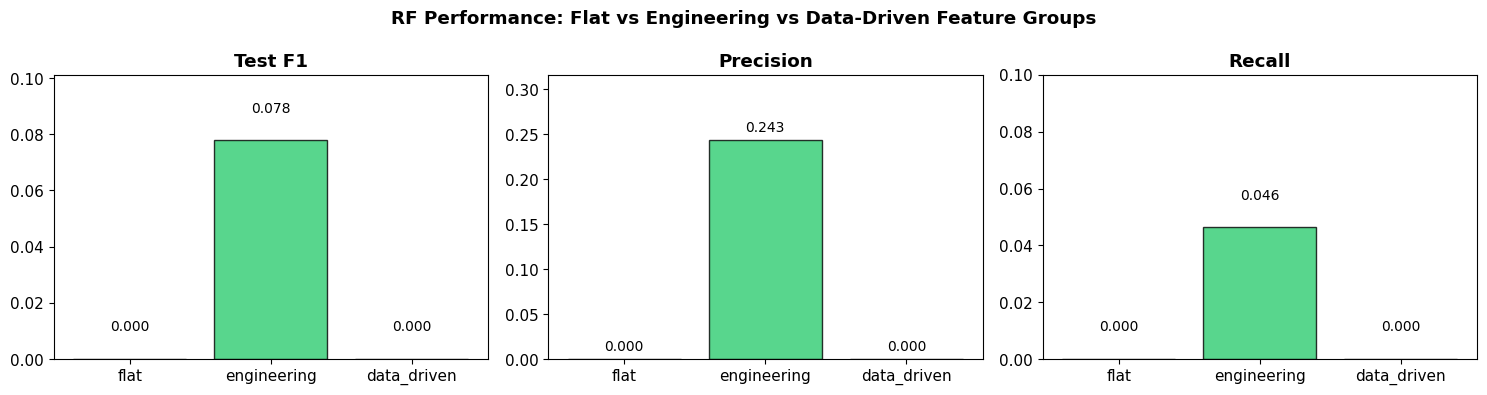

In [9]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modes = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e67e22']

for ax, metric, title in zip(axes, ['f1_test', 'precision', 'recall'],
                              ['Test F1', 'Precision', 'Recall']):
    vals = [results[m][metric] for m in modes]
    bars = ax.bar(modes, vals, color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, max(max(vals) * 1.3, 0.1))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('RF Performance: Flat vs Engineering vs Data-Driven Feature Groups', fontweight='bold')
plt.tight_layout()
plt.show()

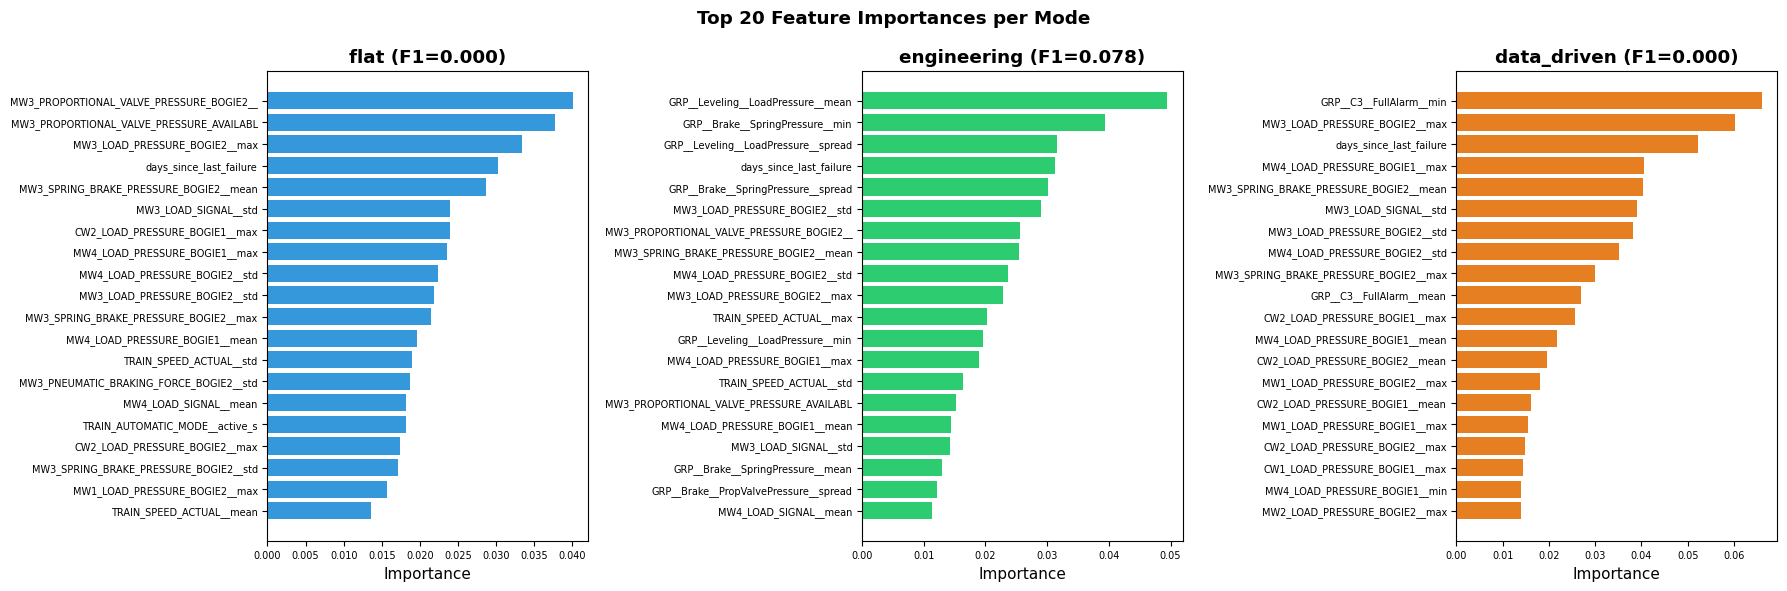

In [10]:
# Top 20 feature importances for each mode
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (mode_name, X_tr) in zip(axes, [('flat', train_flat), ('engineering', train_eng), ('data_driven', train_dd)]):
    rf = results[mode_name]['model']
    feat_names = X_tr.columns.tolist()
    importances = rf.feature_importances_
    top_idx = np.argsort(importances)[-20:]
    
    ax.barh([feat_names[i][:40] for i in top_idx], importances[top_idx], color=colors[list(results.keys()).index(mode_name)])
    ax.set_title(f'{mode_name} (F1={results[mode_name]["f1_test"]:.3f})', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.tick_params(labelsize=7)

plt.suptitle('Top 20 Feature Importances per Mode', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Export Results

In [ ]:
# Save full comparison (v1 + v2)
res_path = os.path.join('..', 'outputs', 'model_comparison.csv')
comp_df.to_csv(res_path, index=False)
print(f'Saved {len(comp_df)} model results to {res_path}')

# Save test predictions for best overall model (by tuned test F1)
best_row = comp_df.loc[comp_df['f1_test'].idxmax()]
best_model_name = best_row['model']
best_feat_mode = best_row['features']
print(f'\nBest overall: {best_model_name} + {best_feat_mode} → Test F1={best_row["f1_test"]:.3f}')

# Find the actual model object
if best_model_name == 'RF-Shallow':
    best_model_obj = results[best_feat_mode]['model']
    best_threshold = 0.5
else:
    key = f'{best_model_name}__{best_feat_mode}'
    best_model_obj = results_v2[key]['model']
    best_threshold = results_v2[key]['best_threshold']

best_X_test = datasets[best_feat_mode][1].fillna(0).values
best_proba = best_model_obj.predict_proba(best_X_test)[:, 1]
best_preds = (best_proba >= best_threshold).astype(int)

pred_df = test_meta.copy()
pred_df['prediction'] = best_preds
pred_df['probability'] = best_proba
pred_df['model'] = best_model_name
pred_df['features'] = best_feat_mode
pred_df['threshold'] = best_threshold
pred_path = os.path.join('..', 'outputs', 'test_predictions.csv')
pred_df.to_csv(pred_path, index=False)
print(f'Saved {len(pred_df):,} test predictions to {pred_path}')